In [ ]:
# 슈도코드
# 무신사 사이트에 접속한다
# 상단 검색바를 클릭한다
# 인기검색어의 1위 키워드를 서칭한다 -> 니트
# 니트 키워드를 입력해서 실제 니트 상품(plp) 들어가
# 니트 관련 삼품 목록에서 인기 상품 5개 선정
# 인기 상품 5개 각각의 PDP 접속
# 각 상품별 리뷰 목록 확인
# 해당 리뷰를 수집해오기
# 수집한걸로 엑셀 저장
# 엑셀 -> MySQL 저장

In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from webdriver_manager.chrome import ChromeDriverManager
import time

URL = "https://www.musinsa.com/main/musinsa/recommend?gf=A"

service = Service(ChromeDriverManager().install())
options = Options()

# options.add_argument("--headless")
# options.add_argument("--disable-gpu")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("--start-maximized")
options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36")
options.add_argument("--lang=ko_KR")
options.add_argument("--no-sandbox")

driver = webdriver.Chrome(service=service, options=options)
driver.get(URL)
time.sleep(2)

search_butten = driver.find_element(By.CLASS_NAME, "Searchbar__TextFieldWrap-sc-dzagxs-2")
search_butten.click()
time.sleep(2)

popular_keywords = driver.find_element(By.CLASS_NAME, "search-home-popular-wrap")
items = popular_keywords.find_elements(By.TAG_NAME, "li")
target_keyword = items[0].text
time.sleep(2)

search_input = driver.find_element(By.CLASS_NAME, "search-home-search-bar-keyword")
search_input.clear()
search_input.send_keys(target_keyword)
search_input.send_keys(Keys.RETURN) # 엔터 누르는것도 하나의 키
time.sleep(2)

print("타겟키워드 :", target_keyword)
print("페이지 타이틀 :", driver.title)



driver.quit()

타겟키워드 : 후드집업
페이지 타이틀 : 후드집업 | 무신사 추천 상품


In [3]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import re # 정규표현식의 약자

URL = "https://www.musinsa.com/main/musinsa/recommend?gf=A"

service = Service(ChromeDriverManager().install())
options = Options()

# options.add_argument("--headless")
# options.add_argument("--disable-gpu")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("--start-maximized")
options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36")
options.add_argument("--lang=ko_KR")
options.add_argument("--no-sandbox")

driver = webdriver.Chrome(service=service, options=options)
driver.get(URL)
time.sleep(2)

search_butten = driver.find_element(By.CLASS_NAME, "Searchbar__TextFieldWrap-sc-dzagxs-2")
search_butten.click()
time.sleep(2)

popular_keywords = driver.find_element(By.CLASS_NAME, "search-home-popular-wrap")
items = popular_keywords.find_elements(By.TAG_NAME, "li")
target_keyword = items[0].text
time.sleep(2)

search_input = driver.find_element(By.CLASS_NAME, "search-home-search-bar-keyword")
search_input.clear()
search_input.send_keys(target_keyword)
search_input.send_keys(Keys.RETURN) # 엔터 누르는것도 하나의 키
time.sleep(2)

product_data = []

for _ in range(2) :
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

    products = driver.find_elements(By.CSS_SELECTOR, "div.sc-cpclqO.jrLXZA")[:5]
    
    for product in products :
        try :
            product_info = product.find_element(By.CSS_SELECTOR, "div.sc-itBLYH.cDYUnS")
            brand = product_info.find_element(By.CSS_SELECTOR, "span.text-etc_11px_semibold").text.strip()
            name = product_info.find_element(By.CSS_SELECTOR, "span.text-body_13px_reg").text.strip()
            url = product_info.find_element(By.CSS_SELECTOR, "a.gtm-select-item").get_attribute("href")
            review_infos = product.find_elements(By.CSS_SELECTOR, "span.text-etc_11px_reg.text-yellow.font-pretendard")
            review_rating = float(review_infos[0].text.strip()) if len(review_infos) > 0 else ""    
            review_count_before = review_infos[1].text.strip() if len(review_infos) > 1 else ""    
            review_count = int(re.sub(r"[^\d]" , "", review_count_before))
            
            product_data.append({"브랜드명": brand, "상품명": name, "URL": url, "평점": review_rating, "리뷰수": review_count})
        except Exception as e :
            print("데이터 크롤링 실패 :", e)
            continue
    


df = pd.DataFrame(product_data)
df_top10 = df.sort_values(by="리뷰수", ascending=False).head(10).reset_index(drop=True) # 리뷰수는 내림차순정렬. 기본적으로는 오름차순정렬이다


driver.quit()
df_top10
# df.head() # head는 상위 5개의 값을 가져오라는 뜻

KeyError: '리뷰수'

In [27]:
from openpyxl import Workbook


driver = webdriver.Chrome(service=service, options=options)
all_reviews = list()

for index, row in df_top10.iterrows() :
    print(f"{index + 1}번째 상품리뷰 수집 중 :", row["상품명"])
    driver.get(row["URL"])
    time.sleep(2)

    try :
        review_tab = driver.find_element(By.CSS_SELECTOR, "button[data-button-id='prd_review_tab']")
        review_tab.click()
        time.sleep(2)

        review_elements = driver.find_elements(By.CSS_SELECTOR, "div.ExpandableContent__Container-sc-1951ro-0 > div.ExpandableContent__ContentContainer-sc-1951ro-1 span.text-body_13px_reg.w-full.text-black.font-pretendard")
        for review in review_elements :

            text = (review.text or "").strip()

            if not text :
                continue

            
            all_reviews.append({
                "브랜드": row["브랜드명"],
                "상품명": row["상품명"],
                "URL": row["URL"],
                "리뷰수": row["리뷰수"],
                "리뷰": review.text.strip(),
                "평점": row["평점"],
            })
            print(review.text.strip())

    except Exception as e :
        print("리뷰 수집 실패 :", e)
        continue


driver.quit()

wb = Workbook()
ws = wb.active
ws.tltle = "무신사 리뷰"
ws.append(["브랜드", "상품명", "URL", "리뷰수", "리뷰", "평점"])

for item in all_reviews :
    ws.append([item["브랜드"], item["상품명"], item["URL"], item["리뷰수"], item["리뷰"], item["평점"]])

file_name = "musinsa_top10_review.xlsx"
wb.save(file_name)

print("엑셀파일 저장완료 :", file_name)

1번째 상품리뷰 수집 중 : 2Way 후드 패딩 아크틱 라이트웨이트 히트 점퍼
세일을 많이해 싼맛에 샀는데 테무 알리에서 옷을 가져왔나 차라리 로켓배송으로 받는 쿠팡서 파는 2만원 짜리보다못한 패딩이고 경량패딩이라 요즘같은 계절엔 얼어죽기 딱좋구요. 블랙은 무광인데 조금연하고 아
딱 생각했던 널널한 사이즈예요. 보온성은 아직 입고 밖에 나가질 않아서 잘 모르겠지만, 일단 가볍고 좋아요~ 후드 구멍 크기는 생각보다 작은데 깊이는 괜찮아욤
그냥 휘뚤마뚤 입으려고 샀어용 마감이 막 좋진 않은데 싸게 사서 만족합니다 😋👍
따듯하고 이 가격에 이렇게 따듯하게 입을 수가 없네요. 
디자인도 색감 이쁘고 가벼워서 좋습니다 갓성비
너무 예쁘고 사이즈도 잘 맞고 좋습니다^^ 잘 입겠습니다~
가볍고 따뜻하고 가성비템!
핏도예쁘고 너무 맘에 들어 4개구입
아이 사줬는데 질도 너무좋고 가볍고 따뜻해서 가족잠바로 3개 더 시켰는데 너무좋아서 더시키려고보니 가격이 ㅜㅜ 더시킬껄흑
일단 영하 날씨에 입어도 따뜻하고요 핏고 너무 예쁘고 색깔이 진짜 예뻐요 코디 하기도 너무 쉬워요
빠른배송 좋은품질 친절서비스 최고입니다.
가성비 갑이네요~
다만 실밥 정리가 많이 안되었네요.
색깔에쁜데 보온성은 십중에 3이구용 가성비 좋습니당 헤헷
2번째 상품리뷰 수집 중 : Edelweiss Quilted Jacket Navy
예쁘고 퀄좋고 세일해서 득템했네요 디네댓 믿고 삼
디네뎃 브랜드에 맞게 잘 나온 옷입니다. 마감도 훌륭하고 원단도 좋고 디자인도 이쁘네요. 다만 소매길이랑 기장이 조금 길어서 그 점만 참고하시면 될 것 같아요.
디네뎃 브랜드에 맞게 잘 나온 옷입니다. 마감도 훌륭하고 원단도 좋고 디자인도 이쁘네요. 다만 소매길이랑 기장이 조금 길어서 그 점만 참고하시면 될 곳 같아요.
덩치가 큰데도 루즈핏이네요 좋아요 껴입으면 초겨울까지는 입을수있을듯요
루즈핏이구요 딱붙게 입으시려면 정사이즈보다 한치수 작게입으시면될듯 전 류즈하게 잘맞네요
배송빠르게 잘받았습니다
경량느낌에 가벼운 패딩 좋습니다
간절

In [47]:
import pandas as pd
import re
import hashlib # 특정 문자를 hash처리(암호화) 할 수 있게 도와주는 라이브러리 
# import pymysql # 파이썬과 SQL을 연결시켜주는 모듈 (약식)
from sqlalchemy import create_engine, text # 파이썬과 SQL을 연결시켜주는 모듈 (좀 더 안정석/ 실무)

EXCEL_PATH = "musinsa_top10_review.xlsx"
HOST = "127.0.0.1"
PSSSWORD = "ksdir8558"
PORT = 3306
USER = "root"
DB = "musinsa_db"

df = pd.read_excel(EXCEL_PATH)

ENGINE = create_engine(f"mysql+pymysql://{USER}:{PSSSWORD}@{HOST}:{PORT}/{DB}?charset=utf8mb4", pool_pre_ping=True, pool_recycle=3600)

df.columns = [str(c).strip() for c in df.columns] # [브랜드, 상품명, URL, 리뷰수, 리뷰, 평점]
needed = ["브랜드", "상품명", "URL", "리뷰수", "리뷰", "평점"]
missing = [c for c in needed if c not in df.columns]

if missing :
    raise ValueError(f"엑셀에서 해당 컬럼을 찾지 못했습니다 : {missing}")

def extract_product_id(url: str) -> int | None :
    if not url :
        return None
    m = re.search(r"/products/(\d+)", str(url))
    return int(m.group(1)) if m else None

def sha1_text(s: str) -> str :
    s = (s or "").strip()
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

out = pd.DataFrame()
out["brand"] = df["브랜드"].astype(str).str.strip()
out["product_name"] = df["상품명"].astype(str).str.strip()
out["url"] = df["URL"].astype(str).str.strip()
out["product_id"] = out["url"].apply(extract_product_id)
out["review_count"] = df["리뷰수"]
out["rating"] = df["평점"]
out["review_text"] = (
    df["리뷰"].astype(str)
    .str.replace("\u200b", "", regex=False) # 화이트스페이스값 없애기
    .str.replace("\xa0", " ", regex=False) # 이스케이프 시퀀스 값을 여백 1개로 줄이기
    .str.replace(r"\s+", " ", regex=True) # 정규표현식으로 여러개 공백을 1개로 줄이기
    .str.strip()
)
out["review_hash"] = out["review_text"].apply(sha1_text)
out["source_file"] = EXCEL_PATH
out = out[out["review_text"].notna() & (out["review_text"] != "")]
out = out.drop_duplicates(subset=["review_hash"])

INSERT_SQL = text(""" 
INSERT INTO musinsa_reviews
(brand, product_name, product_id, url, review_count, rating, review_text, review_hash, source_file)
VALUES
(:brand, :product_name, :product_id, :url, :review_count, :rating, :review_text, :review_hash, :source_file)
ON DUPLICATE KEY UPDATE
    rating = VALUES(rating),
    review_count = VALUES(review_count),
    product_name = VALUES(product_name),
    brand = VALUES(brand),
    url = VALUES(url),
    source_file = VALUES(source_file);
""")


def chunked(iterable, size: int) :
    for i in range(0, len(iterable), size) :
        yield iterable[i:i+size]

records = out.to_dict(orient="records") # 하나의 행을 중심으로 딕셔너리 형태로 바꿔라

CHUNK_SIZE = 2000

with ENGINE.begin() as conn :
    for batch in chunked(records, CHUNK_SIZE) :
        conn.execute(INSERT_SQL, batch)

print(f"완료 : {len(records)}건 처리 완료")

완료 : 89건 처리 완료


In [48]:
import pandas as pd
from sqlalchemy import create_engine

MYSQL_USER = "root"
MYSQL_PW = "ksdir8558"
MYSQL_HOST = "127.0.0.1"
MYSQL_PORT = 3306
MYSQL_DB = "musinsa_db"

ENGINE = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PW}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}?charset=utf8mb4", 
    pool_pre_ping=True, # 접속이 잘 되고 있는지 확인
    pool_recycle=3600
)

# 파이썬 문법이 아니기 떄문에 이렇게 씀
query = """ 
SELECT id, brand, product_name, product_id, url, review_count, rating, review_text, created_at
FROM musinsa_reviews
ORDER BY id DESC
LIMIT 100;
"""

df = pd.read_sql_query(query, ENGINE)
df.head()

,id,brand,product_name,product_id,url,review_count,rating,review_text,created_at
0,89,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,경량패딩은 정말 가성비가 중요헌데. 딱 알맞은 가격의 패딩이여서 너무 조음 근데 쫌...,2026-02-05 17:46:34
1,88,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,가성비 최고에 가볍고 따뜻해요 브라운 색깔 고급스럼고 이뻐여,2026-02-05 17:46:34
2,87,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,사이즈 널널하구 가성비좋아여 특별할건없구요 전투복ㄱㄱ,2026-02-05 17:46:34
3,86,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,좋아요 따듯하고 그냥 무탠다드보다 스포츠 경량이 더 예쁜것같아요 무난무난,2026-02-05 17:46:34
4,85,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,컬러감 좋고 스타일 좋음 광택 과하지 않아 굳 핏도 레귤러 핏이라 좋음,2026-02-05 17:46:34


In [49]:
import pandas as pd
import plotly.express as px

df["review_len"] = df["review_text"].fillna("").str.len()
df["rating_num"] = pd.to_numeric(df["rating"], errors="coerce") # to_numeric() : 특정한 값을 수치데이터로 바꾸는 함수

df

,id,brand,product_name,product_id,url,review_count,rating,review_text,created_at,review_len,rating_num
0,89,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,경량패딩은 정말 가성비가 중요헌데. 딱 알맞은 가격의 패딩이여서 너무 조음 근데 쫌...,2026-02-05 17:46:34,52,4.9
1,88,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,가성비 최고에 가볍고 따뜻해요 브라운 색깔 고급스럼고 이뻐여,2026-02-05 17:46:34,33,4.9
2,87,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,사이즈 널널하구 가성비좋아여 특별할건없구요 전투복ㄱㄱ,2026-02-05 17:46:34,29,4.9
3,86,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,좋아요 따듯하고 그냥 무탠다드보다 스포츠 경량이 더 예쁜것같아요 무난무난,2026-02-05 17:46:34,40,4.9
4,85,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,컬러감 좋고 스타일 좋음 광택 과하지 않아 굳 핏도 레귤러 핏이라 좋음,2026-02-05 17:46:34,39,4.9
...,...,...,...,...,...,...,...,...,...,...,...
84,5,엔티비씨,2Way 후드 패딩 아크틱 라이트웨이트 히트 점퍼,5406681,https://www.musinsa.com/products/5406681,64,4.7,너무 예쁘고 사이즈도 잘 맞고 좋습니다^^ 잘 입겠습니다~,2026-02-05 17:46:34,32,4.7
85,4,엔티비씨,2Way 후드 패딩 아크틱 라이트웨이트 히트 점퍼,5406681,https://www.musinsa.com/products/5406681,64,4.7,따듯하고 이 가격에 이렇게 따듯하게 입을 수가 없네요. 디자인도 색감 이쁘고 가벼워...,2026-02-05 17:46:34,56,4.7
86,3,엔티비씨,2Way 후드 패딩 아크틱 라이트웨이트 히트 점퍼,5406681,https://www.musinsa.com/products/5406681,64,4.7,그냥 휘뚤마뚤 입으려고 샀어용 마감이 막 좋진 않은데 싸게 사서 만족합니다 😋👍,2026-02-05 17:46:34,44,4.7
87,2,엔티비씨,2Way 후드 패딩 아크틱 라이트웨이트 히트 점퍼,5406681,https://www.musinsa.com/products/5406681,64,4.7,딱 생각했던 널널한 사이즈예요. 보온성은 아직 입고 밖에 나가질 않아서 잘 모르겠지...,2026-02-05 17:46:34,88,4.7


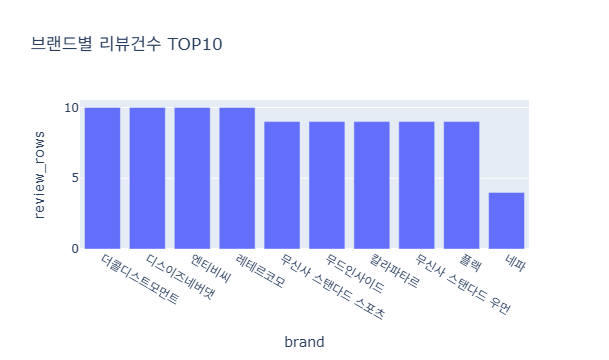

In [50]:
# 브랜드별 리뷰건수 시각화

brand_cnt = (
    df.groupby("brand")["id"]
    .count().reset_index(name="review_rows")
    .sort_values("review_rows", ascending=False)
    .head(10)
)

# fig = px.bar(어떤 데이터가 올것인지, x=, y=, title=)
fig = px.bar(brand_cnt, x="brand", y="review_rows", title="브랜드별 리뷰건수 TOP10")
fig.show()

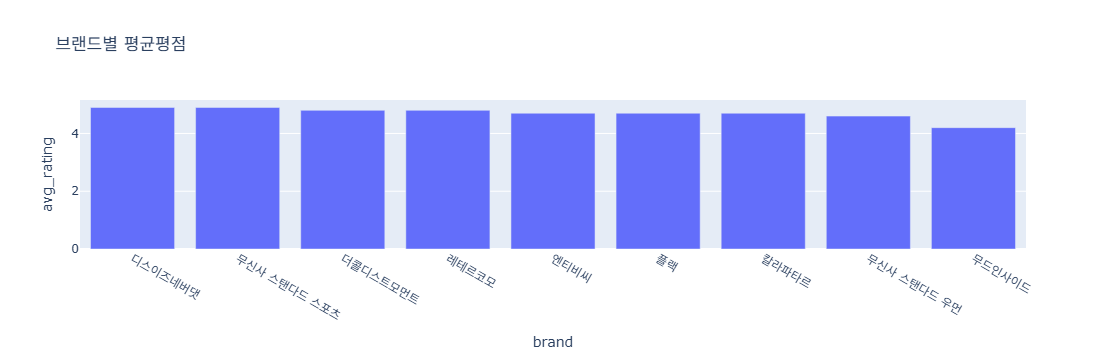

In [51]:
# 브랜드별 평균평점

#매서드 체인 기법
brand_rating = (
    df.dropna(subset=["rating_num"])
    .groupby("brand")["rating_num"]
    .agg(avg_rating="mean", n="count")
    .reset_index() 
)

brand_rating = (
    brand_rating[brand_rating["n"] >= 5]
    .sort_values("avg_rating", ascending=False)
    .head(10)
)

fig = px.bar(brand_rating, x="brand", y="avg_rating", hover_data=["n"], title="브랜드별 평균평점")
fig.show()

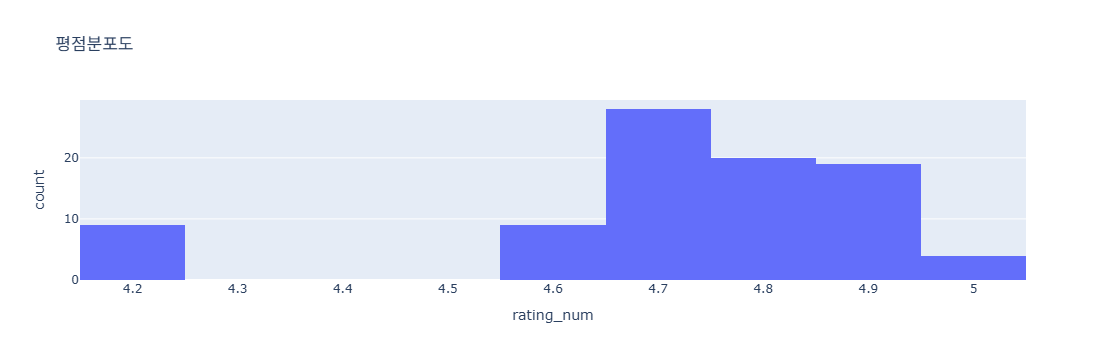

In [52]:
# 히스토그램 : 분포도를 볼 수 있는 차트 -> 어느 지점에 값이 몰려 있는지를 보고자 할때 사용
# 장점 - 전체 데이터를 몇개의 구간으로 나누어서 볼 것인지 결정할수있다

fig = px.histogram(df.dropna(subset=["rating_num"]), x="rating_num", nbins=10, title="평점분포도")

fig.show()

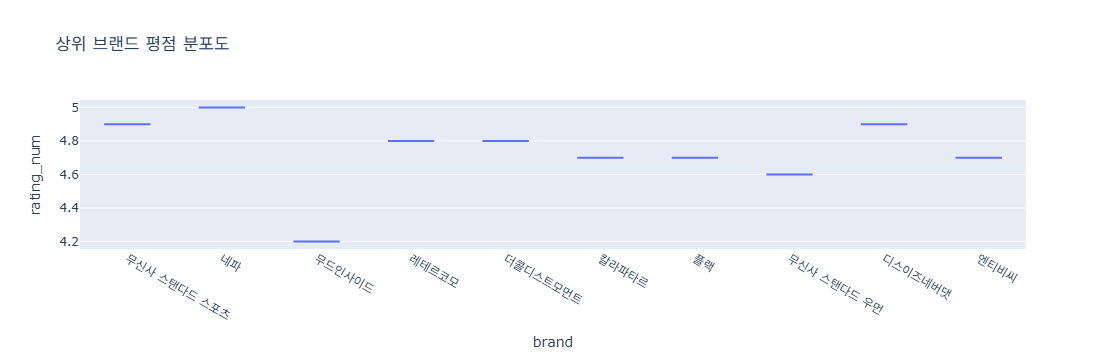

In [53]:
# 박스플롯 차트
# 4분위 그래프 정보 : 중앙값, 1사분위, 3사분위, 편차, 분산, 표준편차, 이상치
import plotly.express as px

top_brands = brand_cnt["brand"].head(10).tolist()

tmp = df[df["brand"].isin(top_brands) & df["rating_num"].notna()]

fig = px.box(tmp, x="brand", y="rating_num", title="상위 브랜드 평점 분포도")

fig.show()

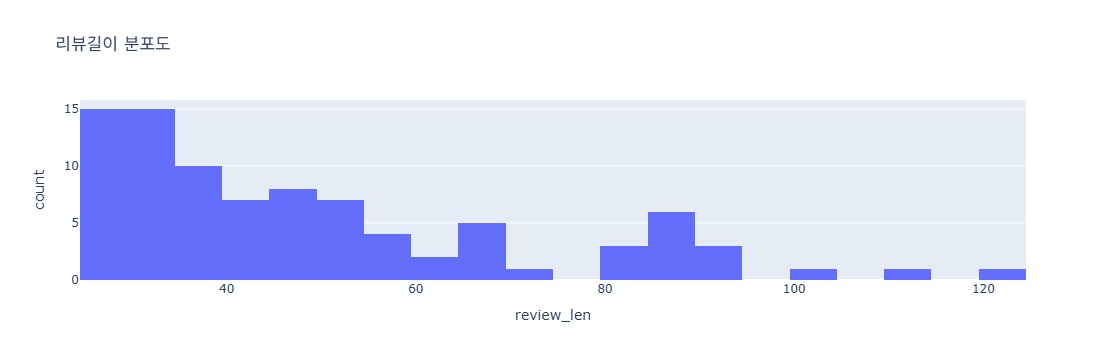

In [34]:
# 리뷰 길이(문자수) 분포

fig = px.histogram(df, x="review_len", nbins=30, title="리뷰길이 분포도")

fig.show()


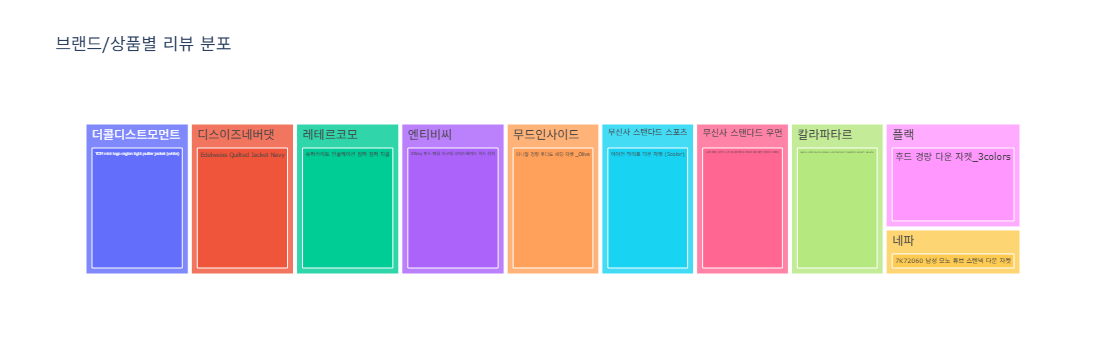

In [54]:
# 트리맵 : 상위 카테고리 > 하위 카테고리
# 상위 기준으로 하위요소가 얼마나 비율을 차지하는가

tree = (
    df.groupby(["brand", "product_name"])["id"]
    .count()
    .reset_index(name="review_rows")
)

tree
# fig = px.treemap(어떤 데이터를 트리 맵으로 사용할지, 해당 데이터의 트리 경로, 해당 경로 안에 기준 값, 차트 이름)
fig = px.treemap(tree, path=["brand", "product_name"], values="review_rows", title="브랜드/상품별 리뷰 분포")

fig.show()

In [39]:
df

,id,brand,product_name,product_id,url,review_count,rating,review_text,created_at,review_len,rating_num
0,89,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,경량패딩은 정말 가성비가 중요헌데. 딱 알맞은 가격의 패딩이여서 너무 조음 근데 쫌...,2026-02-05 17:46:34,52,4.9
1,88,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,가성비 최고에 가볍고 따뜻해요 브라운 색깔 고급스럼고 이뻐여,2026-02-05 17:46:34,33,4.9
2,87,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,사이즈 널널하구 가성비좋아여 특별할건없구요 전투복ㄱㄱ,2026-02-05 17:46:34,29,4.9
3,86,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,좋아요 따듯하고 그냥 무탠다드보다 스포츠 경량이 더 예쁜것같아요 무난무난,2026-02-05 17:46:34,40,4.9
4,85,무신사 스탠다드 스포츠,아이언 라이트 다운 자켓 (5color),4306408,https://www.musinsa.com/products/4306408,1,4.9,컬러감 좋고 스타일 좋음 광택 과하지 않아 굳 핏도 레귤러 핏이라 좋음,2026-02-05 17:46:34,39,4.9
...,...,...,...,...,...,...,...,...,...,...,...
84,5,엔티비씨,2Way 후드 패딩 아크틱 라이트웨이트 히트 점퍼,5406681,https://www.musinsa.com/products/5406681,64,4.7,너무 예쁘고 사이즈도 잘 맞고 좋습니다^^ 잘 입겠습니다~,2026-02-05 17:46:34,32,4.7
85,4,엔티비씨,2Way 후드 패딩 아크틱 라이트웨이트 히트 점퍼,5406681,https://www.musinsa.com/products/5406681,64,4.7,따듯하고 이 가격에 이렇게 따듯하게 입을 수가 없네요. 디자인도 색감 이쁘고 가벼워...,2026-02-05 17:46:34,56,4.7
86,3,엔티비씨,2Way 후드 패딩 아크틱 라이트웨이트 히트 점퍼,5406681,https://www.musinsa.com/products/5406681,64,4.7,그냥 휘뚤마뚤 입으려고 샀어용 마감이 막 좋진 않은데 싸게 사서 만족합니다 😋👍,2026-02-05 17:46:34,44,4.7
87,2,엔티비씨,2Way 후드 패딩 아크틱 라이트웨이트 히트 점퍼,5406681,https://www.musinsa.com/products/5406681,64,4.7,딱 생각했던 널널한 사이즈예요. 보온성은 아직 입고 밖에 나가질 않아서 잘 모르겠지...,2026-02-05 17:46:34,88,4.7


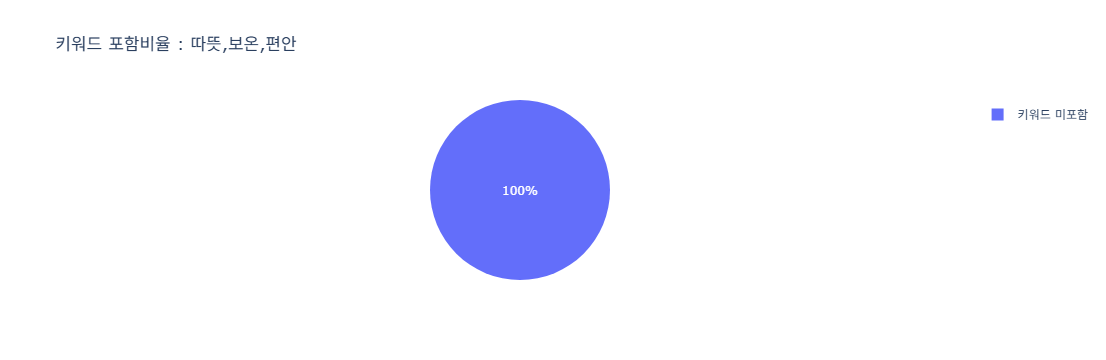

In [56]:
# 특정 키워드를 가지고 있는 리뷰 분포도를 파이차트로 보여주기

keywords_list = ["따뜻", "보온", "편안"]
pattern = "".join(keywords_list)
# 따뜻|보온|편안

df["has_keyword"] = df["review_text"].fillna("").str.contains(pattern)

pie = df["has_keyword"].value_counts().reset_index()
pie["has_keyword"] = pie["has_keyword"].map({
    True: "키워드 포함",
    False: "키워드 미포함"
})

 
fig = px.pie(pie, names="has_keyword", values="count", title=f"키워드 포함비율 : {",".join(keywords_list)}")

fig.show()

In [ ]:
# 워드클라우드 : 단어의 사용정도에 따라서 어떤 단어가 많이 언급되었는가
# 형태소 분석 후 구글 클라우드 전송

# 무신사 프로젝트 종료

In [66]:
import pandas as pd
from kiwipiepy import Kiwi
from collections import Counter # 집계

TEXT_COL = "리뷰"

path = "musinsa_top10_review.xlsx"
df = pd.read_excel(path)

kiwi = Kiwi()

def tokens_only(text: str) :
    if not text :
        return ""
    tokens = kiwi.tokenize(text)
    return " ".join([t.form for t in tokens])

def morph_pos(text: str) :
    if not text :
        return ""
    tokens = kiwi.tokenize(text)
    return " ".join([f"{t.form}/{t.tag}" for t in tokens])

def nouns_only(text: str) :
    if not text :
        return "" 
    tokens = kiwi.tokenize(text)
    nouns = [t.form for t in tokens if t.tag in ("NNG", "NNP", "NNB")] # NNG(일반명사), NNP(고유명사), NNB(의존명사)
    return " ".join(nouns)
    
df["kiwi_tokens"] = df[TEXT_COL].apply(tokens_only)
df["kiwi_morph_pos"] = df[TEXT_COL].apply(morph_pos) # morphology : 형태소
df["kiwi_nouns"] = df[TEXT_COL].apply(nouns_only)

all_nouns = " ".join(df["kiwi_nouns"].fillna("").tolist()).split()
counter = Counter([w for w in all_nouns if len(w) >= 2])

top50 = pd.DataFrame(counter.most_common(50), columns=["noun", "count"])

out_path = "musinsa_tpo10_reviews_kiwi_result.xlsx"

with pd.ExcelWriter(out_path, engine="openpyxl") as writer :
    df.to_excel(writer, index=False, sheet_name="reviews_with_kiwi")
    top50.to_excel(writer, index=False, sheet_name="noun_top50")

print(f"엑셀 파일 저장 완료 : {out_path}")

엑셀 파일 저장 완료 : musinsa_tpo10_reviews_kiwi_result.xlsx


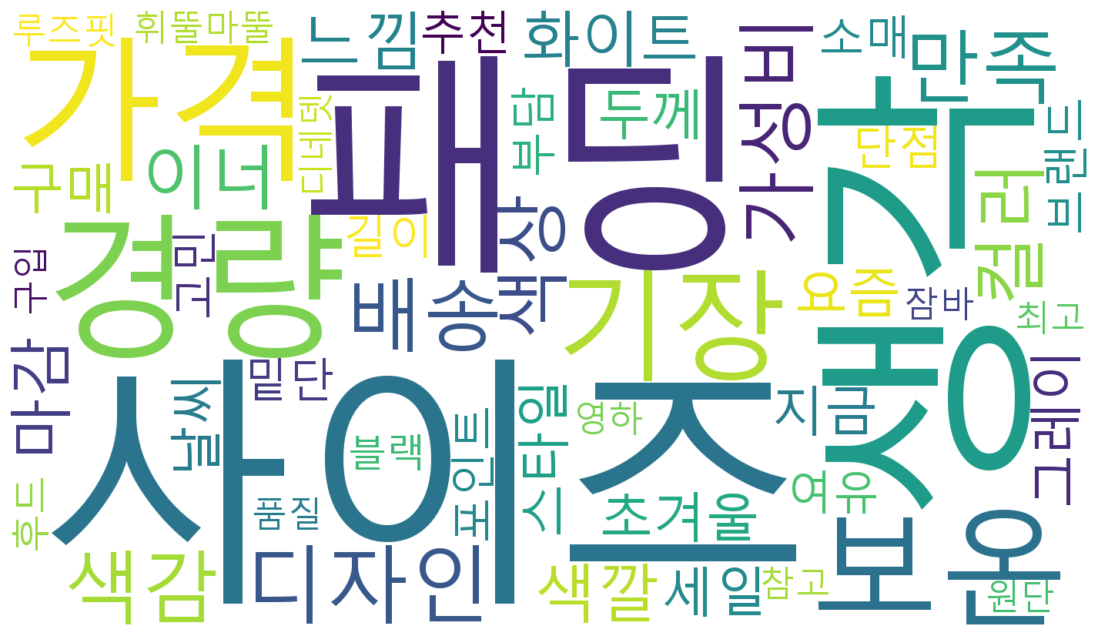

In [78]:
import pandas as pd # 엑셀 데이터 찾아오기
import matplotlib.pyplot as plt # 그림을 그릴때 컨버스 역할을 한다
from wordcloud import WordCloud

path = "musinsa_tpo10_reviews_kiwi_result.xlsx"
df_wc = pd.read_excel(path, sheet_name="noun_top50")

freq_dict = dict(zip(df_wc["noun"], df_wc["count"])) # zip으로 하나로 묶고 dic로 변환 (?)
# list(freq_dict.items())[:10]

#fonts ="/System/Library/Font/AppleGothic.ttf" 맥의 경우
fonts = r"C:\Windows\Fonts\malgun.ttf"

wc = WordCloud(
    font_path=fonts,
    width=1400,
    height=800,
    background_color="#fff"        
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(14, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

out_pqth = "noun_top50_wordcloud.png"
wc.to_file(out_pqth)

1. 구글 클라우드 접속 -> 신규 프로젝트 생성 -> 해당 프로젝트 선택
2. 구글 스프레드 시트 API 허용 -> 구글 API 서비스 -> Google Sheet API 
3. 구글 드라이브 API 사용 -> Google Drive API -> API 사용중지가 나오면 잘 된것
4. 구글에 사용자 인증 정보 서비스 계정 생성 -> 키 만들기
5. 구글 스프레드 시트로 가서 키 등록 (접근권한 등록) -> 새 시트를 만들고 내 메일로 공유(이 때 생성한 키에서 메일 주소가 필요하다)

In [80]:
!pip install  gspread

In [85]:
import gspread
import pandas as pd
from google.oauth2.service_account import Credentials

EXCEL_PATH = "musinsa_tpo10_reviews_kiwi_result.xlsx"
SHEET_NAMES = ["reviews_with_kiwi", "noun_top50"]
SERVICE_ACCOUNT_JSON = "cobalt-verve-486607-e5-5433da577306.json"
SPREADSHEET_URL = "https://docs.google.com/spreadsheets/d/1zGSuOH0aOJVCBTMyLL29LuHM3423U7DsnhHh7UOBfC0/edit?gid=0#gid=0"

SCOPES = [
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive"
]

creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_JSON, scopes=SCOPES)
gc = gspread.authorize(creds)

if "SPREADSHEET_URL" in globals() and SPREADSHEET_URL.split() : 
    sh = gc.open_by_url(SPREADSHEET_URL) 

def upload_df_to_worksheet(sh, ws_name, df) :
    df = df.copy()

    df = df.where(pd. notnull(df), "")

    try :
        ws = sh.worksheet(ws_name)
    except gspread.WorksheetNotFound : 
        rows = max(1000, len(df) + 10)
        cols = max(26, len(df.columns) + 5)
        ws = sh.add_worksheet(title=ws_name, rows=rows, cols=cols)

    ws.clear()

    values = [df.columns.tolist()] + df.astype(str).values.tolist()

    ws.resize(rows=len(values), cols=len(df.columns))

    ws.update(values, value_input_option="RAW")

for name in SHEET_NAMES :
    df_sheet = pd.read_excel(EXCEL_PATH, sheet_name=name)
    upload_df_to_worksheet(sh, name, df_sheet)
    print(f"Uploaded : {name}")

print("Done!")

Uploaded : reviews_with_kiwi
Uploaded : noun_top50
Done!


In [82]:
values = [df.columns.tolist()] + df.astype(str).values.tolist()
values

[['브랜드',
  '상품명',
  'URL',
  '리뷰수',
  '리뷰',
  '평점',
  'kiwi_tokens',
  'kiwi_morph_pos',
  'kiwi_nouns'],
 ['엔티비씨',
  '2Way 후드 패딩 아크틱 라이트웨이트 히트 점퍼',
  'https://www.musinsa.com/products/5406681',
  '64',
  '세일을 많이해 싼맛에 샀는데 테무 알리에서 옷을 가져왔나 차라리 로켓배송으로 받는 쿠팡서 파는 2만원 짜리보다못한 패딩이고 경량패딩이라 요즘같은 계절엔 얼어죽기 딱좋구요. 블랙은 무광인데 조금연하고 아',
  '4.7',
  '세일 을 많이 하 어 싸 ᆫ 맛 에 사 었 는데 테 무 알 리 에서 옷 을 가져오 었 나 차라리 로켓 배송 으로 받 는 쿠팡 서 파 는 2 만 원 짜리 보다 못 하 ᆫ 패딩 이 고 경량 패딩 이 라 요즘 같 은 계절 에 ᆫ 얼 어 죽 기 딱 좋 구요 . 블랙 은 무 광 이 ᆫ데 조금 연하 고 아',
  '세일/NNG 을/JKO 많이/MAG 하/VV 어/EC 싸/VA ᆫ/ETM 맛/NNG 에/JKB 사/VV 었/EP 는데/EC 테/NNG 무/NNG 알/NNG 리/NNG 에서/JKB 옷/NNG 을/JKO 가져오/VV 었/EP 나/EC 차라리/MAG 로켓/NNG 배송/NNG 으로/JKB 받/VV-R 는/ETM 쿠팡/NNP 서/NNG 파/NNG 는/JX 2/SN 만/NR 원/NNG 짜리/NNB 보다/JKB 못/MAG 하/XSA ᆫ/ETM 패딩/NNG 이/VCP 고/EC 경량/NNG 패딩/NNG 이/VCP 라/EC 요즘/NNG 같/VA 은/ETM 계절/NNG 에/JKB ᆫ/JX 얼/VV 어/EC 죽/VV 기/ETN 딱/MAG 좋/VA 구요/EF ./SF 블랙/NNP 은/JX 무/XPN 광/NNG 이/VCP ᆫ데/EC 조금/MAG 연하/VA 고/EC 아/IC',
  '세일 맛 테 무 알 리 옷 로켓 배송 쿠팡 서 파 원 짜리 패딩 경량 패딩 요즘 계절 블랙 광'],
 ['엔티비씨',
 

In [15]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from webdriver_manager.chrome import ChromeDriverManager
import time

URL = "https://www.tiobe.com/tiobe-index/"

service = Service(ChromeDriverManager().install())
options = Options()

# options.add_argument("--headless")
# options.add_argument("--disable-gpu")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("--start-maximized")
options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36")
options.add_argument("--lang=ko_KR")
options.add_argument("--no-sandbox")

driver = webdriver.Chrome(service=service, options=options)
driver.get(URL)
time.sleep(2)

# "///tble[@class='table-top20']
# 

lists = driver.find_elements(By.XPATH, "//table[@id='top20']//tr/td[5]")
for title in lists[:10] :
    print(title.text)


driver.quit()

Python
C
Java
C++
C#
JavaScript
Visual Basic
SQL
Delphi/Object Pascal
R


In [2]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import re

URL = "https://www.musinsa.com/main/musinsa/recommend?gf=A"

service = Service(ChromeDriverManager().install())
options = Options()

# options.add_argument("--headless")
# options.add_argument("--disable-gpu")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("--start-maximized")
options.add_argument("--user-agent=Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36")
options.add_argument("--lang=ko_KR")
options.add_argument("--no-sandbox")

driver = webdriver.Chrome(service=service, options=options)
driver.get(URL)
time.sleep(2)

search_button = driver.find_element(By.CLASS_NAME, "Searchbar__TextFieldWrap-sc-dzagxs-2")
search_button.click()
time.sleep(2)

popular_keywords = driver.find_element(By.CLASS_NAME, "search-home-popular-wrap")
items = popular_keywords.find_elements(By.TAG_NAME, "li")
target_keyword = items[0].text
time.sleep(2)

search_input = driver.find_element(By.CLASS_NAME, "search-home-search-bar-keyword")
search_input.clear()
search_input.send_keys(target_keyword)
search_input.send_keys(Keys.RETURN)
time.sleep(2)

product_data = list()

for _ in range(6) :
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

    products = driver.find_elements(By.CSS_SELECTOR, "div.sc-gSifMm.hWcAiF")[:15]

    for product in products :
        try :
            thumbnail_img = product.find_element(By.CSS_SELECTOR, 'div[data-mds="Image"] img')
            thumbnail_url = thumbnail_img.get_attribute("src")
            product_info = product.find_element(By.CSS_SELECTOR, "div.sc-hdBJTi.HekfN")
            brand = product_info.find_element(By.CSS_SELECTOR, "span.sc-dFVmKS.sc-kCuUfV.caMYFJ.fLhMxZ").text.strip()
            name = product_info.find_element(By.CSS_SELECTOR, "span.sc-dFVmKS.sc-dNdcvo.caMYFJ.coaQNK").text.strip()
            url = product_info.find_element(By.CSS_SELECTOR, "a.gtm-select-item").get_attribute("href")
            
            review_infos = product.find_elements(By.CSS_SELECTOR, r"span.text-\[11px\].leading-\[14px\].text-yellow.font-global")           
            rating_text = review_infos[0].text.strip() if len(review_infos) > 0 else ""
            review_rating = float(rating_text) if rating_text else 0
            
            review_count_before = review_infos[1].text.strip() if len(review_infos) > 1 else ""
            review_count_str = re.sub(r"[^\d]", "", review_count_before)
            review_count = int(review_count_str) if review_count_str else 0

            # --- 할인률 / 판매가 ---
            try:
                price_box = product.find_element(By.CSS_SELECTOR, "div.sc-kcLKEh.sc-dntSTA.khlneC.bhsCSX")
                spans = price_box.find_elements(By.CSS_SELECTOR, "span[data-mds='Typography']")
                texts = [sp.text.strip() for sp in spans if sp.text.strip()]
            
                discount_rate = texts[0] if len(texts) >= 2 else ""
                sale_price    = texts[1] if len(texts) >= 2 else (texts[0] if len(texts) == 1 else "")
            except:
                discount_rate = ""
                sale_price = ""


            product_data.append({"브랜드명" : brand, "상품명": name, "썸네일": thumbnail_url, "할인률": discount_rate, "판매가": sale_price, "URL": url, "평점": review_rating, "리뷰수": review_count})
        except Exception as e :
            print("데이터 크롤링 실패 :", e)
            continue

df = pd.DataFrame(product_data)
df_top10 = df.sort_values(by="리뷰수", ascending=False).head(10).reset_index(drop=True)

driver.quit()
df_top10

,브랜드명,상품명,썸네일,할인률,판매가,URL,평점,리뷰수
0,나이스고스트클럽,3STAR LOGO ZIP HOODIE_6colors(NG2EFUM480A),https://image.msscdn.net/thumbnails/images/goo...,35%,"64,350원",https://www.musinsa.com/products/4324664,4.8,972
1,에이지오디,2_WAY 스웨트 후디드 집업 [블랙],https://image.msscdn.net/thumbnails/images/goo...,58%,"18,760원",https://www.musinsa.com/products/3469896,4.7,849
2,더블유브이프로젝트,더스트 피그먼트 후드집업 다크그레이 MJOT7437,https://image.msscdn.net/thumbnails/images/goo...,36%,"49,800원",https://www.musinsa.com/products/1621921,4.7,845
3,일리고,129 로고 패치 후드 집업 블랙,https://image.msscdn.net/thumbnails/images/goo...,21%,"74,000원",https://www.musinsa.com/products/3651031,4.7,697
4,노르딕아일랜드,DW N로고 후드집업 - 네이비,https://image.msscdn.net/thumbnails/images/goo...,35%,"57,850원",https://www.musinsa.com/products/2285140,4.7,228
5,썬번프로젝트,"Logo Patch Hoodie Zip-up, PURPLE",https://image.msscdn.net/thumbnails/images/goo...,15%,"118,150원",https://www.musinsa.com/products/5333962,4.8,169
6,어반디타입,어반스텔라 스웻 후드 집업_5color,https://image.msscdn.net/thumbnails/images/goo...,52%,"37,990원",https://www.musinsa.com/products/5281249,4.9,158
7,이알티알,Ad Astra Appliqué 2way Hoodie Zip Up Grey,https://image.msscdn.net/thumbnails/images/goo...,31%,"89,000원",https://www.musinsa.com/products/4826665,4.8,130
8,오와이,PRAY HARD HOODIE ZIP UP - BLACK,https://image.msscdn.net/thumbnails/images/goo...,30%,"76,300원",https://www.musinsa.com/products/5345813,4.9,129
9,글랙,[글랙 × 지꾸] GZHD001 헤이즈 와플 집업 후드 (GREEN),https://image.msscdn.net/thumbnails/images/goo...,,"89,000원",https://www.musinsa.com/products/5390372,4.9,118


In [15]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import re

URL = "https://www.musinsa.com/main/musinsa/recommend?gf=A"

service = Service(ChromeDriverManager().install())
options = Options()

# options.add_argument("--headless")
# options.add_argument("--disable-gpu")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("--start-maximized")
options.add_argument("--user-agent=Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36")
options.add_argument("--lang=ko_KR")
options.add_argument("--no-sandbox")

driver = webdriver.Chrome(service=service, options=options)
driver.get(URL)
time.sleep(2)

search_button = driver.find_element(By.CLASS_NAME, "Searchbar__TextFieldWrap-sc-dzagxs-2")
search_button.click()
time.sleep(2)

popular_keywords = driver.find_element(By.CLASS_NAME, "search-home-popular-wrap")
items = popular_keywords.find_elements(By.TAG_NAME, "li")
target_keyword = items[0].text
time.sleep(2)

search_input = driver.find_element(By.CLASS_NAME, "search-home-search-bar-keyword")
search_input.clear()
search_input.send_keys(target_keyword)
search_input.send_keys(Keys.RETURN)
time.sleep(2)

product_data = list()

for _ in range(2) :
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

    products = driver.find_elements(By.CSS_SELECTOR, "div.sc-gSifMm.hWcAiF")[:3]

    for product in products :
        try :
            thumbnail_img = product.find_element(By.CSS_SELECTOR, 'div[data-mds="Image"] img')
            thumbnail_url = thumbnail_img.get_attribute("src")
            product_info = product.find_element(By.CSS_SELECTOR, "div.sc-hdBJTi.HekfN")
            brand = product_info.find_element(By.CSS_SELECTOR, "span.sc-dFVmKS.sc-kCuUfV.caMYFJ.fLhMxZ").text.strip()
            name = product_info.find_element(By.CSS_SELECTOR, "span.sc-dFVmKS.sc-dNdcvo.caMYFJ.coaQNK").text.strip()
            url = product_info.find_element(By.CSS_SELECTOR, "a.gtm-select-item").get_attribute("href")
            
            review_infos = product.find_elements(By.CSS_SELECTOR, r"span.text-\[11px\].leading-\[14px\].text-yellow.font-global")           
            rating_text = review_infos[0].text.strip() if len(review_infos) > 0 else ""
            review_rating = float(rating_text) if rating_text else 0
            
            review_count_before = review_infos[1].text.strip() if len(review_infos) > 1 else ""
            review_count_str = re.sub(r"[^\d]", "", review_count_before)
            review_count = int(review_count_str) if review_count_str else 0

            # --- 할인률 / 판매가 ---
            try:
                price_box = product.find_element(By.CSS_SELECTOR, "div.sc-kcLKEh.sc-dntSTA.khlneC.bhsCSX")
                spans = price_box.find_elements(By.CSS_SELECTOR, "span[data-mds='Typography']")
                texts = [sp.text.strip() for sp in spans if sp.text.strip()]
            
                discount_rate = texts[0] if len(texts) >= 2 else ""
                sale_price    = texts[1] if len(texts) >= 2 else (texts[0] if len(texts) == 1 else "")
            except:
                discount_rate = ""
                sale_price = ""


            product_data.append({"브랜드명" : brand, "상품명": name, "썸네일": thumbnail_url, "할인률": discount_rate, "판매가": sale_price, "URL": url, "평점": review_rating, "리뷰수": review_count})
        except Exception as e :
            print("데이터 크롤링 실패 :", e)
            continue

df = pd.DataFrame(product_data)
df_top3 = df.sort_values(by="리뷰수", ascending=False).head(3).reset_index(drop=True)

driver.quit()
df_top3

,브랜드명,상품명,썸네일,할인률,판매가,URL,평점,리뷰수
0,제멋,헤븐 투웨이 테리 후드집업 8종 버건디 KJHD2523,https://image.msscdn.net/thumbnails/images/goo...,29%,"33,210원",https://www.musinsa.com/products/3551178,4.8,587
1,코드그라피,(우먼) 코튼 후드 집업_3color,https://image.msscdn.net/thumbnails/images/goo...,82%,"18,000원",https://www.musinsa.com/products/3837517,4.9,49
2,오운서,[블루클로젯 X 오운서] 마이 그래니 스티치 퍼 후드 집업 (퍼 탈부착 가능_2 C...,https://image.msscdn.net/thumbnails/images/goo...,40%,"82,800원",https://www.musinsa.com/products/5727484,4.9,17


1. 인스타그램은 로그인 과정이 필요하다
2. 매번 크롤링 할때마다 로그인을 수동으로 할 필요없이 최초에 한번만 로그인 과정을 진행하고 두번째 부터는 로그인 요구하지 않게 설정
3. 로그인이 필요한 모든 사이트에 적용할 수 있음
4. 데스크탑으로 접근 가능한 인스타그램 아이디 & 패스워드 필요

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from webdriver_manager.chrome import ChromeDriverManager
import time
import pickle

# URL = "https://www.instagram.com/accounts/login/"

service = Service(ChromeDriverManager().install())
options = Options()

# options.add_argument("--headless")
# options.add_argument("--disable-gpu")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("--start-maximized")
options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36")
options.add_argument("--lang=ko_KR")
options.add_argument("--no-sandbox")

driver = webdriver.Chrome(service=service, options=options)
driver.get(URL)

print("수동으로 로그인 후 40초 안에 인증을 완료해주세요")
time.sleep(40)

with open("insragram_cookies.pkl", "wb") as f :
    pickle.dump(driver.get_cookies(), f)

print("쿠키 저장 완료")
driver.quit()

In [8]:
df_top1

,브랜드명,상품명,썸네일,할인률,판매가,URL,평점,리뷰수
0,코드그라피,(우먼) 코튼 후드 집업_3color,https://image.msscdn.net/thumbnails/images/goo...,82%,"18,000원",https://www.musinsa.com/products/3837517,4.9,49


In [17]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from urllib.parse import quote, urlparse # quote : 예상치못한 요소들을 인코딩 시켜준다 // urlparse : 원하는 위치의 값을 가져온다
import re
import time
import pickle


URL = "https://www.instagram.com/"

service = Service(ChromeDriverManager().install())
options = Options()

# options.add_argument("--headless")
# options.add_argument("--disable-gpu")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("--start-maximized")
options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36")
options.add_argument("--lang=ko_KR")
options.add_argument("--no-sandbox")

driver = webdriver.Chrome(service=service, options=options)
driver.get(URL)

# Repactoring을 위한 유틸리티 함수
def wait_post_loaded(driver, timeout) :
    wait = WebDriverWait(driver, timeout)
    wait.until(EC.presence_of_element_located((By.TAG_NAME, "main")))
    wait.until(lambda d: len(d.find_elements(By.XPATH, "//main//a[@href]")) > 0) # d는 wait가 가지고 있는 드라이버라는 객체가 들어온다

def find_scroll_contaniner_in_main(driver) :
    main = driver.find_element(By.TAG_NAME, "main")
    canditates = main.find_elements(By.XPATH, ".//*[contains(@class, 'x78zum5') or contains(@style, 'overflow')]")


    # 인스타그램은 찾아올 수 이 있는 식별자가 없어서 이렇게 할 수밖에 없다 
    best = None
    best_h = 0

    for el in canditates :
        try :
            h = driver.execute_script("return arguments[0].clientHeight;", el) #클라이언트하이트 : 눈에 보이는 화면
            sh = driver.execute_script("return arguments[0].scrollHeight;", el) #스크롤하이트 : 스크롤할 수 있는 숨겨져 있는 전체화면

            if sh > h and h > best_h : 
                best = el
                best_h = h
        except : 
            pass
    return best

def scroll_inside(driver, el, max_round, pause) :
    last = -1 # 0이나 양수를 넣으면 의도치않게 스크롤이 멈출 수 있기 때문에 절대 나올 수 없는 음수를 일부러 넣었다
    for _ in range(max_round) : 
        driver.execute_script("arguments[0].scrollTop = arguments[0].scrollHeight;", el)
        time.sleep(pause)
        cur = driver.execute_script("return arguments[0].scrollTop;", el) # 연속으로 하지 않는 이유? -> 스크롤을 더 이상 할 수 없는 상황인지를 판단하기 위해
        if cur == last : # 스크롤이 불가능한 상황 // 예외조항처리
            break
        last = cur

def extract_username_from_href(href) :
    if not href:
        return None

    path = urlparse(href).path.strip("/")

    if not path :
        return None

    if path.startswith(("p/", "reel/", "tv/", "explre/", "accounts/")) :
        return None

    username = path.split("/")[0]

    if re.fullmatch(r"[A-Za-z0-9._]{1,30}", username) : # fullmatch : 명확하게 같은 패턴만 찾아와라
        return username

    return None

    # url = "https://www.instagram.com/musinsa.official/" 이라는 경로가 있다고 가정
    # parsed = urlparse(url)
    # parsed = {"scheme":"https", "netloc":"https://www.instagram.com", "path":"/musinsa.official/"}

def get_author_id(driver) :
    main = driver.find_element(By.TAG_NAME, "main")
    anchors = main.find_elements(By.XPATH, ".//a[@href]")

    best = None
    best_y = 10**9

    for a in anchors :
        href = a.get_attribute("href") or ""
        username = extract_username_from_href(href)

        if not username :
            continue

        txt = a.text.strip()
        if txt.startswith("@") :
            continue

        try :
            y = a.location["y"]
            if y < best_y :
                best_y = y
                best = username

        except :
            pass
            
    return best

def get_comments(driver) :
    comments = [] 
    main = driver.find_element(By.TAG_NAME, "main")
    spans = main.find_elements(By.XPATH, ".//span[@dir='auto' and not(ancestor::*[@role='button'])]")

    for s in spans :
        t = s.text.strip()

        if not t :
            continue

        if re.fullmatch(r"\s\d+\s*(주|일|시간|분|초)", t) :
            continue

        if len(t) <= 1 :
            continue

        comments.append(t)

        # 정규표현식 : 특정한 형태의 패턴을 가지고 있는 문자열을 찾아내고 싶을 때 사용
        #(주|일|시간|분|초) : | = vertical ban => 또는 이라는 뜻
        # \s* : * => 0개 또는 그 이상을 표현 => 아무것도 존재하지 않을 수도 있고, 복수의 값이 있을 수도 있다
        # \s : 여백, 공백 등의 화이트스페이스 (예, '10 주', '10주' 모두 허용)
        # \d+ : + => 1개 이상이 존재한다 / \d => 정수(숫자) 

    seen = set()
    uniq = []
    
    for c in comments :
        if c not in seen :
            seen.add(c)
            uniq.append(c)
    return uniq

    

with open("instagram_cookies.pkl", "rb") as f :
    cookies = pickle.load(f)

for cookie in cookies : 
    driver.add_cookie(cookie)

driver.refresh()
time.sleep(10)

try : 
    btn = driver.find_element(By.XPATH, "//button[normalize-space()='나중에 하기' or normalize-space()='정보 저장']")
    btn.click()
    time.sleep(2)
except :
    pass

print("정상적인 로그인 후 나중에 하기 버튼 클릭 완료")

base_url = "https://www.instagram.com"
results = []

brands = (
    df_top3["브랜드명"]
    .dropna() # 브랜드명 없는건 날려라
    .astype(str) # 공백을 없애기 위해 문자열로 변환해라
    .str.strip() # 혹시라도 있을 공백을 없애라
    .unique() # 중복값은 버리고 하나만 가져와라
    .tolist()) # 리스트로 변환해라

print("브랜드 수: ", len(brands))

for keyword in brands : 
    encoded = quote(keyword) # 한글이나 예상치못한 요소를 인코딩 시켜준다
    tag_url = f"{base_url}/explore/tags/{encoded}"
    driver.get(tag_url)
    time.sleep(5)

    post_link = set()

    for _ in range(2) :
        links = driver.find_elements(By.TAG_NAME, "a")
        for link in links :
            href = link.get_attribute("href")
            if href and "/p/" in href :
                if href.startswith("/p/") :
                    href = base_url + href
                post_link.add(href)
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(3)

    print(f"[{keyword}] 수집된 게시물 수 :", len(post_link))

    for url in list(post_link) : 
        driver.get(url)

        try :
            wait_post_loaded(driver, timeout=15) # 15만 써도 되고 timeout을 따로 선언해서 사용해도 되지만 가독성을 위해 timeout = 15으로 사용
            
            
        except Exception as e :
            print(f"페이지 로딩 실패:, {keyword} | {url} | {e}")
            results.append({"brand": keyword, "url": url, "author_id": None, "comments": []})
            continue # 값을 찾지 못했을때 넘어가 -> 해야하는걸 못했을때 사용

        try :
            scroll_box = find_scroll_contaniner_in_main(driver)
            if scroll_box :
                scroll_inside(driver, scroll_box, max_round=10, pause=1)
        except : 
            pass # 값이 없을수도 있으니까 넘어가 // 예시)댓글이 없음

        try :
            author_id = get_author_id(driver)
            comments = get_comments(driver)
        except Exception as e :
            print(f"추출 실패: {keyword} | {url} | {e}")
            author_id, comments = None, []

        results.append({
            "brand": keyword,
            "url": url,
            "author_id": author_id,
            "comments": comments
        })

driver.quit()

for r in results[:20] :
    print(r["brand"], r["url"])
    print("author", r["author_id"])
    print("comments", r["comments"])
    print("=" * 60)

print("총 결과 수: ", len(results))

정상적인 로그인 후 나중에 하기 버튼 클릭 완료
브랜드 수:  3
[제멋] 수집된 게시물 수 : 18
[코드그라피] 수집된 게시물 수 : 18
[오운서] 수집된 게시물 수 : 18
제멋 https://www.instagram.com/p/CPVKDrSjGa_/
author anyohannnnn
comments ['anyohannnnn', '금정동', 'anyohannnnn\n 수정됨\n•\n247주\n요즘 근황\n#안녕하세요 #소통해요', 'yonnnnng_seok', '232주', '올블랙에 감성진 코디 스타일 너무 좋은데요!? ㅎㅎ 상의 프린팅도 이쁩니다 내년 여름까지 다시 존버하겠습니다😁', 'junnnyonnng', '239주', '크 스타일 너무 좋으세요🙌🙌', 'joozoo_7', '247주', '힙합 서타일이구먼', 'seob1382', '멋있어요~~', 'zzdnrk', '스트릿느낌 🔥', 'y_y9.8', '오우 어디 회사 모델이죠', 'soundrunway', 'xebxeb2', '간지다....', 's_minseo28', '머쨍이', '2021년 5월 26일', '이 게시물에 대한 댓글 기능이 제한되었습니다.']
제멋 https://www.instagram.com/p/CBXOAdGDlU7/
author hmincloset
comments ['hmincloset', 'hmincloset\n 297주\n⠀\n오늘은 오랜만에 카라티를 입었습니다\n입고나서 보니 상체는 흰검 하체는 검흰 순서네요 데칼코마니같네요\n역시 반바지는 넣입보단 빼입이 나은 것 같아요\n상의가 길면 다리가 짧아보이긴하지만 그래도 빼입이 자연스럽네요\n⠀\ntop @jemut_shop\nbottom @8seconds_official\nshoes @sacaiofficial @nike\nbag @anderssonbell\nacc @green_container_\n.\n.\n.\n.\n.\n.\n.\n#dailyfashion #ootdshare #sacainike #sacaiwaff

# 인스타그램 쿠키값 탈취 -> 자동로그인 -> 무신사를 통해서 크롤링한 브랜드명을 가져다가 인스타그램 검색 -> 해당 검색된 브랜드 검색결과 창에서 2번의 스크롤을 통해서 피드 컨텐츠 방문
# 38개의 url을 한번씩 방문하면서 아래와 같은 정보를 다시 찾아오기
# 브랜드명 & 게시글 url & 게시글 작성자 & 게시글 댓글
# 찾아온 데이터를 MySQL로 가져가서 값을 분석

인스타그램 내 페이지 이동을 할 때, 유독 시간이 많이 걸리는 지점이 있다 -> time.sleep()으로 잘 안됨
SPA : 브라우저가 인스타그램 서버에 해당 페이지를 달라고 요청함 -> 컨텐츠를 감싸안고 있는 html, css 같은 구조를 먼저 준 준 후에 js를 주는데 js를 주기 전에 크롤러가 들어가버리면 sleep이 안 먹힌다
이럴땐, 최대로 기다릴 수 있는 시간을 정해놓고 그 시간 이전에 데이터 값을 가져오면 해당 값을 받아서 다음 단계로 바로 넘어가고
최대로 기다릴 수 있는 시간을 초과하면 에러를 발생시키지 말고 그 다음번째 컨텐츠를 다시 찾아오라고 해야한다

lambda식을 쓰는 이유
기본적으로 함수는 구문이다(문장의 형태) 문장의 형태를 띄고 있다는 것은 식+식 = 문 이라는 뜻이다 
함수는 실행요소들이 있고, 그 요소들을 통해 값을 반환한다 이런 문장의 형태는 단점이 있는데, 무언가를 실행하고자할때 문장형식으로 구문을 작성해야한다는 점인데
람다식은 이런 불필요한 문장형식의 구문을 작성해야하는 번거로움을 없앨 수 있다.

어떤 기능을 구형하기 위한 코드를 작성했는데 이 코드를 별도로 떼어내서 관리를 하게된다면 향후 코드의 유지, 보수 및 개선할때 효율적이다 => 리팩토링
굳이 하지 않아도 되지만 효율, 가독, 이식성을 위해 하는 것이 좋다

In [19]:
import pymysql

MYSQL_HOST = "127.0.0.1"
MYSQL_PORT = 3306
MYSQL_USER = "root"
MYSQL_PW = "ksdir8558"
MYSQL_DB = "instagram_review"
MYSQL_CHARSET = "utf8mb4"

rows = []

for r in results : 
    brand = r.get("brand")
    post_url = r.get("url")
    author_id = r.get("author_id")
    comment_text = r.get("comments")

    for c in comment_text :
        c = c.strip()
        rows.append((brand, post_url, author_id, c))

print("DB INSERT 대상 row 수:", len(rows))

conn = pymysql.connect(
    host=MYSQL_HOST,
    port=MYSQL_PORT,
    user=MYSQL_USER,
    password=MYSQL_PW,
    database=MYSQL_DB,
    charset=MYSQL_CHARSET
)

try :
    with conn.cursor() as cur :
        sql = """
        INSERT INTO ig_tag_comments (brand, post_url, author_id, comment_text) 
        VALUES (%s, %s, %s, %s);
        """
# %s => 순서, 순번을 의미
        
        for row in rows :
            cur.execute(sql, row)

    conn.commit()
    print("MYSQL 저장완료!")
        
except Exception as e :
    conn.rollback()
    print("😥저장실패: ", e)

finally :
    conn.close()

DB INSERT 대상 row 수: 1220
MYSQL 저장완료!
